# Projeto 1 - Mineracao de Dados
## Priorizacao de ajuda humanitaria (ONG Help International)

**Objetivo:** pipeline reproduzivel para agrupar paises por **perfis de necessidade
semelhantes**, apoiando a decisao da ONG sobre alocacao de um fundo limitado.

**Produto:** recomendacao baseada em perfis (nao um ranking de paises), usando **4 indicadores**.

**Ordem canonica do pre-processamento (Aula 3):**
`limpar -> tratar outliers -> log (assimetria) -> escalonar -> modelar`.

Este notebook responde as 6 perguntas obrigatorias do enunciado: indicadores, faltantes,
outliers, assimetria, escalonamento e distancia.

---

### Correcoes em relacao a versao anterior (itens da revisao)

1. **Dado limpo nas tabelas finais** - perfil e listagem de paises usam `X_imputed`/`df`,
   nunca `df_raw` (que continha `income = 99999`).
2. **Outliers: deteccao + decisao explicita** (manter / limitar / remover) justificada.
3. **Coerencia scaler x outliers:** mantendo extremos legitimos usamos **`RobustScaler`**
   (mediana + IQR) em vez de `StandardScaler`.
4. **4 indicadores justificados** pelo heatmap de correlacao; reconhece-se a **colinearidade** (sao facetas de um mesmo fator de desenvolvimento), sem vender como "4 dimensoes independentes".
5. **Escolha de `k` discutida** com cotovelo **e** silhueta (mais CH e DB), desempate escrito.
6. **`k=3`** adotado (grupos acionaveis), discutindo o trade-off da silhueta.

### Ajustes menores
- Deteccao de sentinelas ampliada: `99999`, `100000` **e** `999`.
- `total_fer` ganha limite superior plausivel (Argentina=45 -> NaN).
- `warnings.filterwarnings("ignore")` removido.
- Variavel morta removida da auditoria.


## 1. Imports e configuracao


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Repro: semente fixa em TODO o pipeline
SEED = 42
np.random.seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


## 2. Carregamento e EDA inicial

Le o CSV bruto e inspeciona dimensoes, tipos e faltantes reais.


In [2]:
candidatos = [
    Path("data/paises_help_international.csv"),
    Path("../data/paises_help_international.csv"),  # se rodar de dentro de notebooks/
    Path("paises_help_international.csv"),
    Path("/content/paises_help_international.csv"),
]
DATA_PATH = next((p for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Coloque paises_help_international.csv na pasta data/ do projeto."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Base: {DATA_PATH}")
print(f"Dimensoes: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
display(df_raw.head())


Base: ..\data\paises_help_international.csv
Dimensoes: 167 linhas x 18 colunas


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,acesso_agua_pct,acesso_esgoto_pct,acesso_energia_pct,alfabetizacao_pct,internet_pct,medicos_por_1000,extrema_pobreza_pct,cesta_basica_salario_pct
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,53.3,26.1,29.0,52.6,NaN,0.48,57.6,123.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,81.2,64.6,68.1,79.4,50.5,2.40,32.8,65.4
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,74.5,57.7,71.3,83.8,38.1,2.00,31.9,78.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,48.4,16.9,99999.0,59.4,6.9,0.26,68.0,124.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,83.8,76.7,85.0,86.3,65.1,2.61,21.2,49.9


In [3]:
print("Tipos:")
display(df_raw.dtypes.to_frame("tipo"))

print("\nDuplicatas:")
print("Linhas duplicadas:", df_raw.duplicated().sum())
print("Paises unicos:", df_raw['country'].nunique())
print("country e identificador (cardinalidade 100%) -> nao entra no modelo.")

missing_raw = (
    df_raw.isna().sum()
    .sort_values(ascending=False)
    .to_frame("faltantes_reais")
)
print("\nFaltantes reais (vazios explicitos):")
display(missing_raw[missing_raw["faltantes_reais"] > 0])


Tipos:


,tipo
country,str
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64



Duplicatas:
Linhas duplicadas: 0
Paises unicos: 167
country e identificador (cardinalidade 100%) -> nao entra no modelo.

Faltantes reais (vazios explicitos):


,faltantes_reais
acesso_agua_pct,2
internet_pct,2
alfabetizacao_pct,1
child_mort,1
exports,1
total_fer,1
acesso_esgoto_pct,1
acesso_energia_pct,1
life_expec,1
inflation,1


### 2.1 Estatisticas descritivas e assimetria (base bruta)


In [4]:
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

eda_raw = df_raw[num_cols].describe().T
eda_raw["skew"] = df_raw[num_cols].skew()
eda_raw["n_missing"] = df_raw[num_cols].isna().sum()
display(eda_raw.round(3))


,count,mean,std,min,25%,50%,75%,max,skew,n_missing
child_mort,166.0,37.997,40.553,-8.000,7.825,19.250,61.200,208.0,1.467,1
exports,166.0,41.286,28.109,0.109,23.800,35.200,51.375,200.0,2.554,1
health,167.0,611.508,7737.547,1.810,4.920,6.320,8.760,99999.0,12.921,0
imports,167.0,645.489,7734.559,0.066,30.200,43.300,58.900,99999.0,12.923,0
income,167.0,17728.874,20281.825,609.000,3545.000,10400.000,23000.000,125000.0,2.247,0
inflation,166.0,610.447,7760.887,-4.210,1.790,5.265,11.050,100000.0,12.884,1
life_expec,166.0,71.271,13.705,32.100,65.300,73.100,76.800,205.0,5.363,1
total_fer,166.0,3.206,3.598,1.150,1.792,2.410,4.037,45.0,9.644,1
gdpp,167.0,13643.222,19922.189,231.000,1365.000,4680.000,15300.000,119000.0,2.452,0
acesso_agua_pct,165.0,75.055,16.414,40.600,63.200,75.600,87.000,150.0,0.365,2


### 2.2 Graficos de EDA (Aula 4)

Histogramas (forma) e boxplots (outliers) da base bruta.


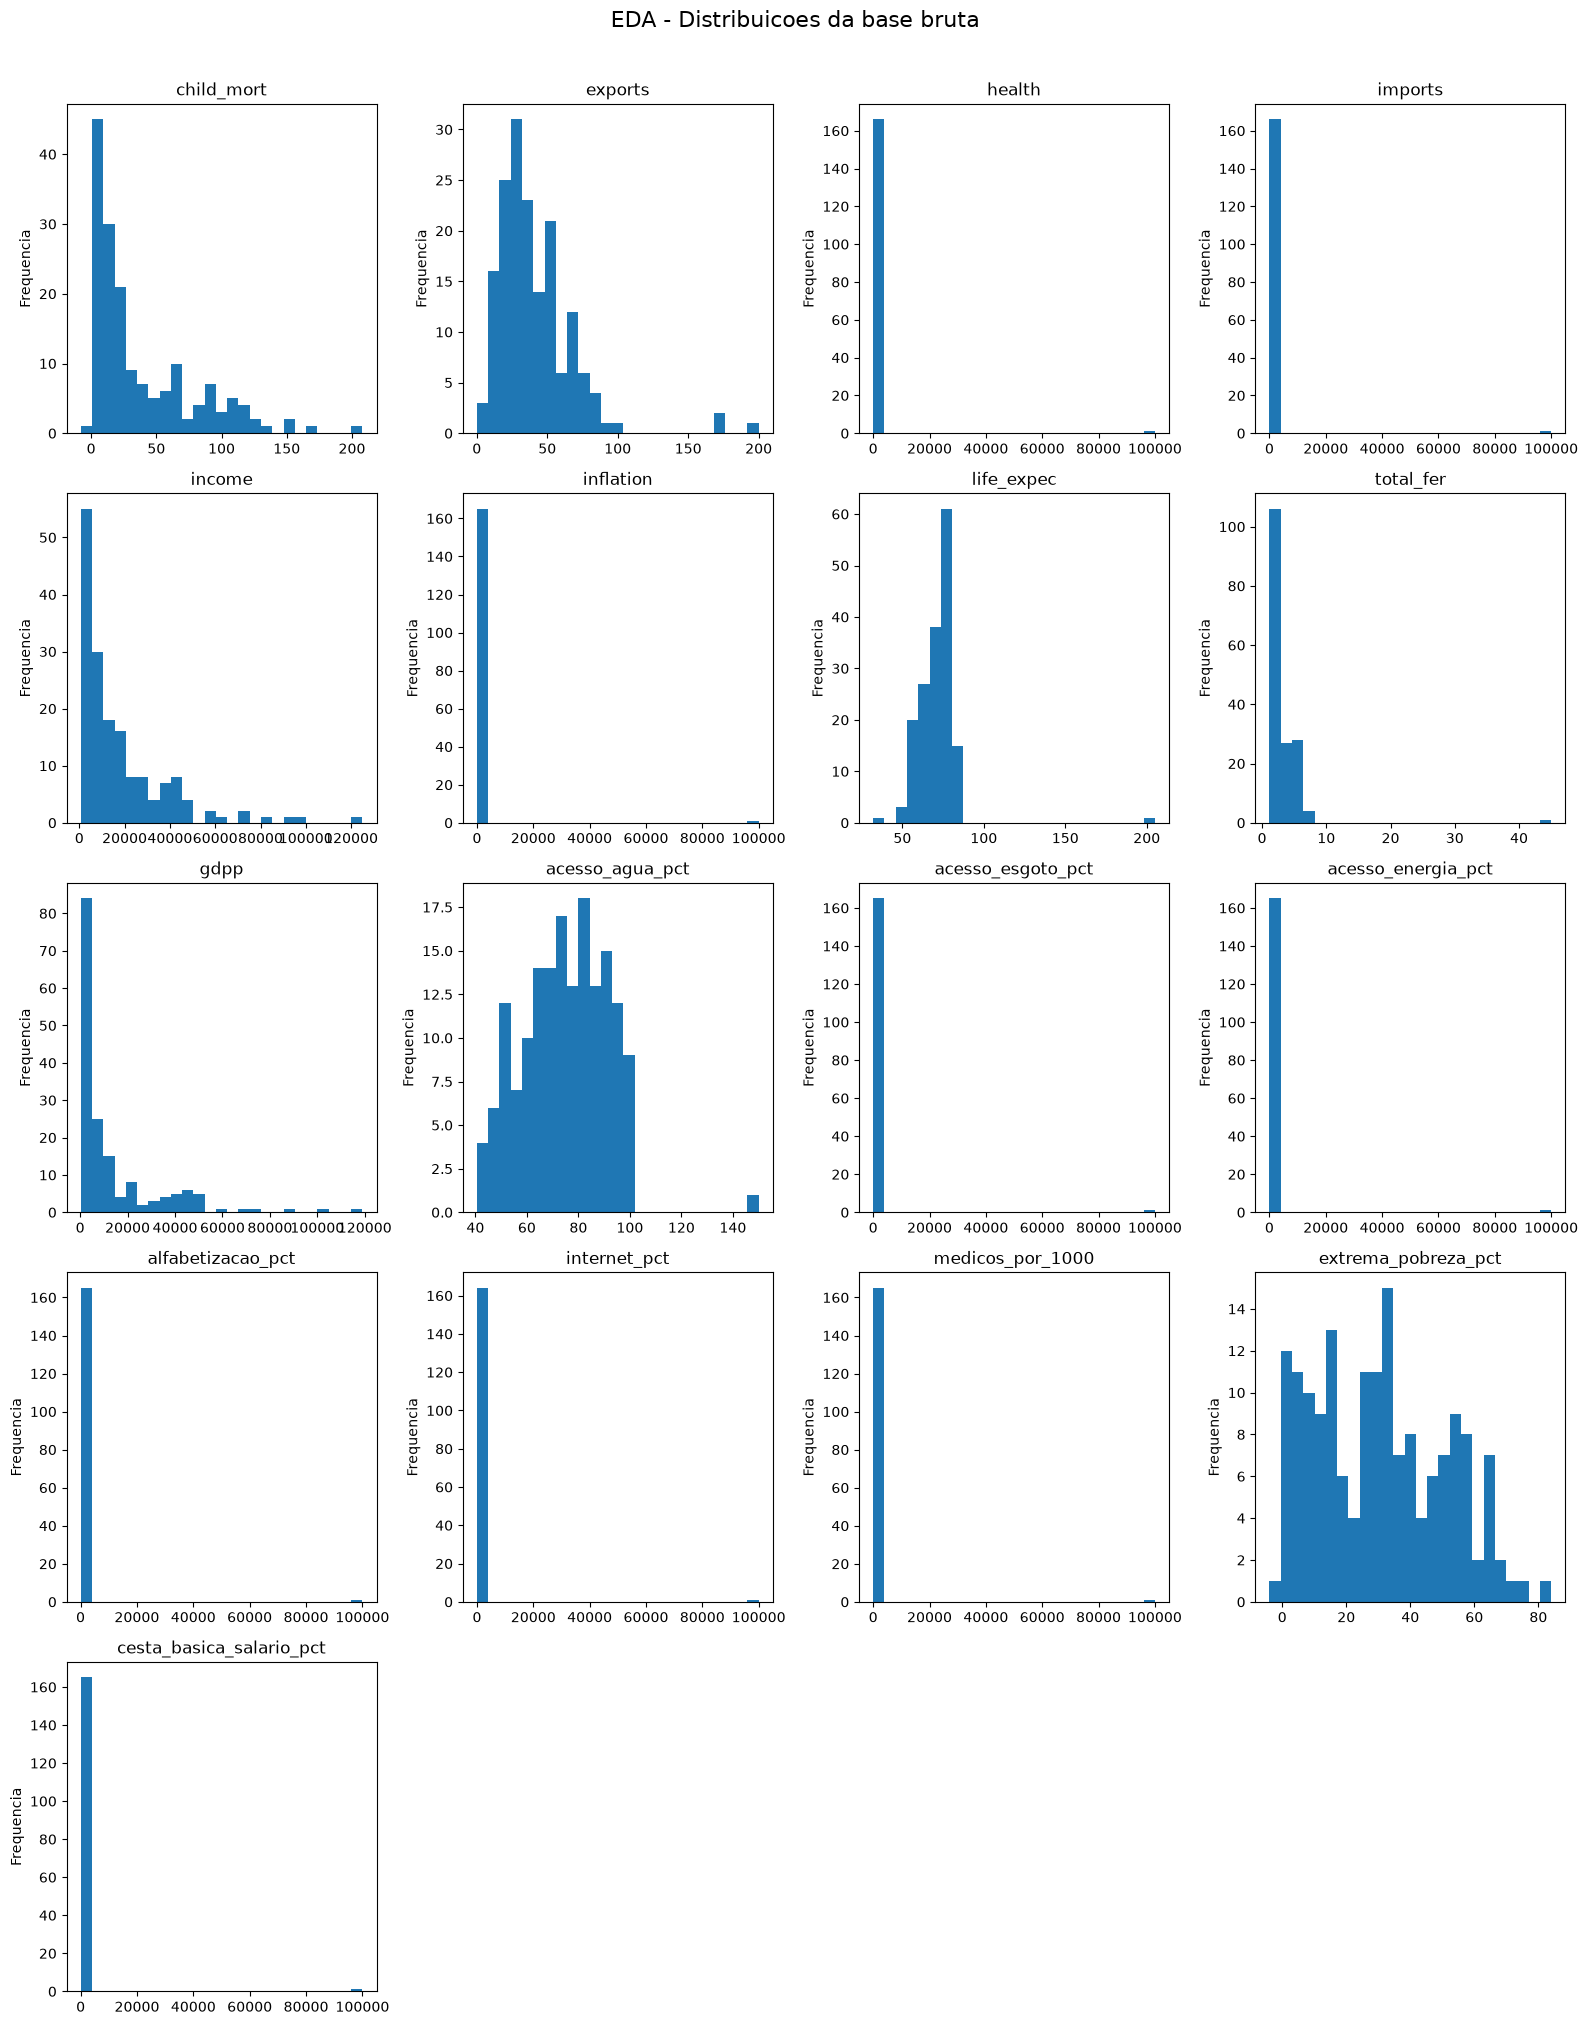

In [5]:
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    ax.hist(df_raw[col].dropna(), bins=25)
    ax.set_title(col)
    ax.set_ylabel("Frequencia")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("EDA - Distribuicoes da base bruta", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


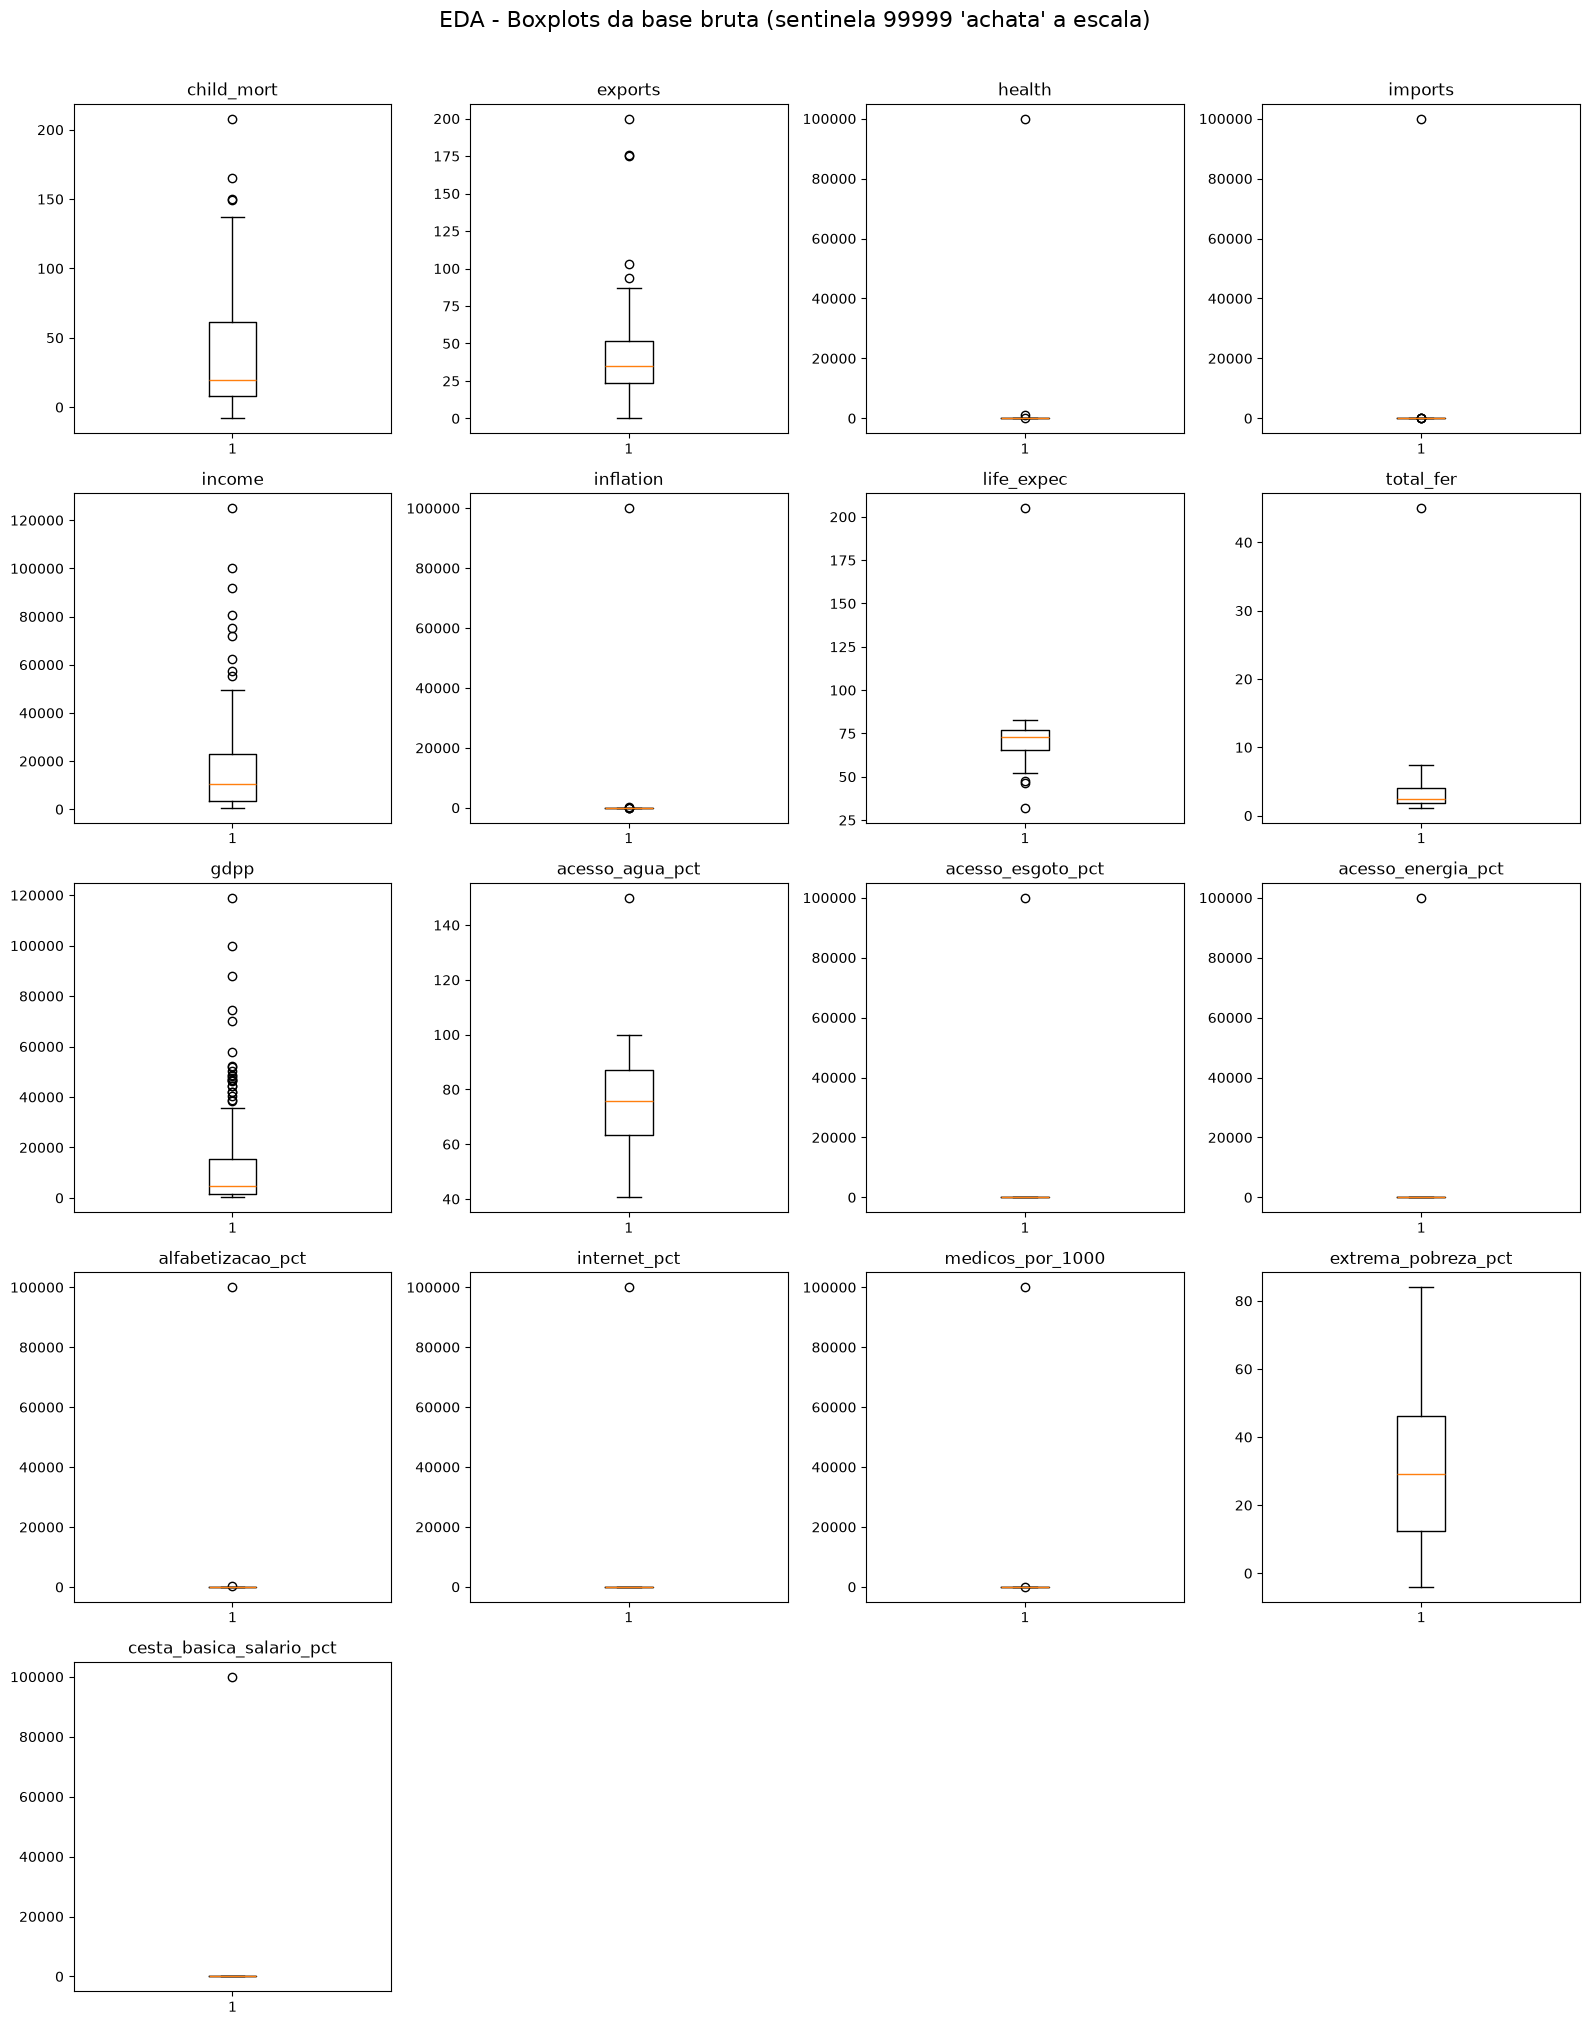

In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    ax.boxplot(df_raw[col].dropna())
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("EDA - Boxplots da base bruta (sentinela 99999 'achata' a escala)", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


## 3. Diagnostico de qualidade (diario de bordo)

Busca ativa pelos problemas: sentinelas, valores impossiveis e extremos.

**Achado da revisao:** a deteccao de sentinelas precisa cobrir tambem o `999`
(Poland `health`), nao apenas `99999/100000`.


In [7]:
# Sentinelas conhecidas: 99999 (ausencia de dado) e 999 (Poland health)
SENTINELAS = [99999, 100000, 999]

sentinelas = []
for col in num_cols:
    contagem = {str(v): int((df_raw[col] == v).sum()) for v in SENTINELAS}
    total = sum(contagem.values())
    if total:
        linha = {"variavel": col}
        linha.update(contagem)
        linha["total"] = total
        sentinelas.append(linha)

sentinelas_df = pd.DataFrame(sentinelas)
print("Sentinelas encontradas (99999 / 100000 / 999):")
display(sentinelas_df if not sentinelas_df.empty
        else pd.DataFrame({"resultado": ["Nenhuma sentinela encontrada"]}))


Sentinelas encontradas (99999 / 100000 / 999):


,variavel,99999,100000,999,total
0,health,1,0,1,2
1,imports,1,0,0,1
2,income,1,0,0,1
3,inflation,0,1,0,1
4,gdpp,1,0,0,1
5,acesso_esgoto_pct,1,0,0,1
6,acesso_energia_pct,1,0,0,1
7,alfabetizacao_pct,1,0,0,1
8,internet_pct,1,0,0,1
9,medicos_por_1000,1,0,0,1


In [8]:
# Valores impossiveis (fora da faixa valida)
DOMAIN_RULES = {
    "health":                   lambda s: (s < 0) | (s > 100),
    "child_mort":               lambda s: s < 0,
    "life_expec":               lambda s: (s <= 0) | (s > 120),
    "total_fer":                lambda s: (s < 0) | (s > 20),   # Argentina=45 fica de fora
    "acesso_agua_pct":          lambda s: (s < 0) | (s > 100),   # Brazil=150
    "acesso_esgoto_pct":        lambda s: (s < 0) | (s > 100),
    "acesso_energia_pct":       lambda s: (s < 0) | (s > 100),
    "alfabetizacao_pct":        lambda s: (s < 0) | (s > 100),   # Kenya=240
    "internet_pct":             lambda s: (s < 0) | (s > 100),   # Peru=-12
    "medicos_por_1000":         lambda s: s < 0,
    "extrema_pobreza_pct":      lambda s: (s < 0) | (s > 100),   # India=-4
    "cesta_basica_salario_pct": lambda s: s < 0,                 # >100 e LEGITIMO!
}

print("Observacao de dominio: em 'cesta_basica_salario_pct' valores > 100 sao")
print("legitimos (a cesta custa mais de um salario minimo em paises pobres).")
print("Apenas valores negativos sao invalidos nessa coluna.\n")

impossiveis = []
for col, regra in DOMAIN_RULES.items():
    if col in df_raw.columns:
        mask = regra(df_raw[col]) & df_raw[col].notna()
        for idx in df_raw.index[mask]:
            impossiveis.append({
                "country": df_raw.loc[idx, "country"],
                "variavel": col,
                "valor": df_raw.loc[idx, col],
            })

impossiveis_df = pd.DataFrame(impossiveis)
print("Valores impossiveis detectados:")
display(impossiveis_df if not impossiveis_df.empty
        else pd.DataFrame({"resultado": ["Nenhum valor impossivel"]}))


Observacao de dominio: em 'cesta_basica_salario_pct' valores > 100 sao
legitimos (a cesta custa mais de um salario minimo em paises pobres).
Apenas valores negativos sao invalidos nessa coluna.

Valores impossiveis detectados:


,country,variavel,valor
0,Guatemala,health,99999.0
1,Poland,health,999.0
2,Chile,child_mort,-8.0
3,Germany,life_expec,205.0
4,Argentina,total_fer,45.0
5,Brazil,acesso_agua_pct,150.0
6,Nepal,acesso_esgoto_pct,99999.0
7,Angola,acesso_energia_pct,99999.0
8,Kenya,alfabetizacao_pct,240.0
9,Zambia,alfabetizacao_pct,99999.0


## 4. Limpeza

**Decisao:** sentinelas e valores impossiveis viram `NaN` (o valor correto e
desconhecido; a imputacao por mediana os trata depois).


In [9]:
df = df_raw.copy()

# 1) sentinelas -> NaN
df[num_cols] = df[num_cols].replace(SENTINELAS, np.nan)

# 2) valores impossiveis -> NaN
for col, regra in DOMAIN_RULES.items():
    if col in df.columns:
        mask = regra(df[col]) & df[col].notna()
        df.loc[mask, col] = np.nan

print("Faltantes apos limpeza (sentinela + impossiveis):")
falta = df.isna().sum().sort_values(ascending=False)
display(falta[falta > 0].to_frame("faltantes"))

# 3) duplicatas
print("\nLinhas duplicadas apos limpeza:", df.duplicated().sum())


Faltantes apos limpeza (sentinela + impossiveis):


,faltantes
internet_pct,4
acesso_agua_pct,3
alfabetizacao_pct,3
child_mort,2
acesso_energia_pct,2
health,2
acesso_esgoto_pct,2
total_fer,2
life_expec,2
inflation,2



Linhas duplicadas apos limpeza: 0


### 4.1 Auditoria (valores alterados na limpeza)

Tabela **sem variavel morta**, mostrando `valor_original -> valor_pos_limpeza`.


In [10]:
def construir_auditoria(df_original, df_limpo, cols):
    linhas = []
    for idx in df_original.index:
        for col in cols:
            orig = df_original.loc[idx, col]
            limpo = df_limpo.loc[idx, col]
            if pd.notna(orig) and pd.isna(limpo):
                status = "sentinela/impossivel -> NaN"
            elif pd.isna(orig) and pd.isna(limpo):
                status = "faltante original (NaN)"
            else:
                continue
            linhas.append({
                "country": df_original.loc[idx, "country"],
                "variavel": col,
                "valor_original": orig,
                "valor_pos_limpeza": limpo,
                "status": status,
            })
    return pd.DataFrame(linhas)

auditoria_limpeza = construir_auditoria(df_raw, df, num_cols)
print("Resumo das alteracoes de limpeza:")
display(auditoria_limpeza["status"].value_counts().to_frame("quantidade"))
print("\nRegistros alterados:")
display(auditoria_limpeza.sort_values(["country", "variavel"]).reset_index(drop=True))


Resumo das alteracoes de limpeza:


,quantidade
status,
sentinela/impossivel -> NaN,19
faltante original (NaN),15



Registros alterados:


,country,variavel,valor_original,valor_pos_limpeza,status
0,Afghanistan,internet_pct,NaN,NaN,faltante original (NaN)
1,Angola,acesso_energia_pct,99999.0,NaN,sentinela/impossivel -> NaN
2,Argentina,total_fer,45.0,NaN,sentinela/impossivel -> NaN
3,Bangladesh,income,99999.0,NaN,sentinela/impossivel -> NaN
4,Bolivia,medicos_por_1000,99999.0,NaN,sentinela/impossivel -> NaN
5,Brazil,acesso_agua_pct,150.0,NaN,sentinela/impossivel -> NaN
6,Chile,child_mort,-8.0,NaN,sentinela/impossivel -> NaN
7,Colombia,cesta_basica_salario_pct,NaN,NaN,faltante original (NaN)
8,Ecuador,life_expec,NaN,NaN,faltante original (NaN)
9,Germany,life_expec,205.0,NaN,sentinela/impossivel -> NaN


## 5. Outliers (decisao obrigatoria)

Deteccao por **IQR** (`Q1-1.5*IQR`, `Q3+1.5*IQR`). Variaveis socioeconomicas tem
cauda longa: muitos "outliers" sao **paises genuinamente ricos ou pobres** - o alvo da ONG.

**Decisao:** os extremos sao majoritariamente **legitimos e informativos** -> **NAO removemos**
registros. Erros grosseiros ja foram tratados na limpeza. Como mantemos outliers, o scaler
adequado e o **`RobustScaler`** (mediana + IQR) - ver secao 8.4.


In [11]:
outliers_iqr = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    outliers_iqr.append({
        "variavel": col,
        "skew": round(s.skew(), 3),
        "limite_inf": round(lower, 2),
        "limite_sup": round(upper, 2),
        "n_outliers": int(mask.sum()),
        "%_outliers": round(mask.mean() * 100, 2),
    })

outliers_iqr = pd.DataFrame(outliers_iqr).sort_values("n_outliers", ascending=False)
display(outliers_iqr)

print("\nDECISAO: manter todos os outliers (nao remover registros).")
print("Motivo: caudas longas = pobreza/riqueza real; remover apagaria o alvo da ONG.")
print("Contrapartida: usar RobustScaler para os extremos nao dominarem a distancia.")


,variavel,skew,limite_inf,limite_sup,n_outliers,%_outliers
8,gdpp,2.421,-18093.75,33776.25,24,14.46
4,income,2.226,-25631.25,51938.75,8,4.82
5,inflation,5.314,-11.92,24.60,5,3.03
1,exports,2.554,-17.56,92.74,5,3.01
0,child_mort,1.468,-73.25,143.15,4,2.42
3,imports,2.031,-12.99,101.91,4,2.41
6,life_expec,-0.957,48.05,94.05,3,1.82
2,health,0.706,-0.70,14.26,1,0.61
7,total_fer,0.947,-1.39,7.09,1,0.61
14,medicos_por_1000,11.821,-2.22,7.10,1,0.61



DECISAO: manter todos os outliers (nao remover registros).
Motivo: caudas longas = pobreza/riqueza real; remover apagaria o alvo da ONG.
Contrapartida: usar RobustScaler para os extremos nao dominarem a distancia.


## 6. Assimetria (decisao obrigatoria)

Escalonar **nao** resolve assimetria: log muda a **forma**, scaler muda a **escala**.
Aplicamos `log1p` apenas onde reduz a assimetria para perto de 0 (renda e mortalidade
infantil), **antes** de escalonar. `exports` nao e indicador escolhido (ver secao 7),
evitando o log exagerado apontado na revisao (skew ia de +2,56 a -1,06).


In [12]:
skew_cols = df[num_cols].skew().sort_values(ascending=False).to_frame("skew")
print("Assimetria (base limpa, antes de transformar):")
display(skew_cols.round(3))

print("\nCauda longa clara em: income, gdpp, child_mort, total_fer, inflation, exports.")


Assimetria (base limpa, antes de transformar):


,skew
medicos_por_1000,11.821
inflation,5.314
exports,2.554
gdpp,2.421
income,2.226
imports,2.031
child_mort,1.468
total_fer,0.947
health,0.706
extrema_pobreza_pct,0.301



Cauda longa clara em: income, gdpp, child_mort, total_fer, inflation, exports.


## 7. Selecao dos 4 indicadores (decisao obrigatoria)

Usamos o **heatmap de correlacao (Pearson)** para analisar redundancia e escolher 4
indicadores que representem as principais facetas de **necessidade humanitaria**.

> **Observacao importante (honestidade sobre os dados):** neste dataset a maioria dos
> indicadores socioeconomicos e **fortemente colinear** - eles medem, no fundo, um
> **unico fator latente de "desenvolvimento/pobreza"**. Os proprios 4 escolhidos tem
> correlacoes altas entre si (`child_mort` x `acesso_agua_pct` = -0,88;
> `child_mort` x `alfabetizacao_pct` = -0,88; `acesso_agua_pct` x `alfabetizacao_pct` = 0,95).
> Ou seja: **nao sao 4 dimensoes independentes**, e sim **4 facetas complementares do
> mesmo eixo de desenvolvimento**. Isso e uma propriedade real dos dados, nao um erro de
> selecao - com este conjunto de colunas, qualquer subconjunto de 4 colapsa na mesma direcao.
> A escolha abaixo **minimiza** a redundancia (evita pares quase identicos) e mantem
> **interpretabilidade para a ONG**, reconhecendo a colinearidade em vez de mascara-la.

**Candidatos rejeitados por redundancia quase total (quase a mesma coluna):**
- `income` x `gdpp`: r=0,89 -> ficamos com **`income`** (renda das familias).
- `acesso_agua_pct` x `acesso_esgoto_pct` (0,96) x `acesso_energia_pct` (0,96) x `internet_pct` (0,95):
  sao praticamente a mesma medida de infraestrutura -> escolhemos **`acesso_agua_pct`**.
- `child_mort` x `life_expec`: r=-0,89 -> ficamos com **`child_mort`** (mais acionavel).
- `child_mort` x `total_fer`: r=0,85 -> `total_fer` redundante com `child_mort`.
- `health` (% do PIB) discrimina pouco (mediana 5,2 x 6,9) e `exports` (% do PIB) mede
  abertura comercial, **nao** necessidade humanitaria -> descartados.

**Os 4 indicadores adotados (4 facetas, cientes da colinearidade):**

| Indicador | Faceta de necessidade | Justificativa |
|---|---|---|
| `child_mort` | Saude infantil | indicador central de vulnerabilidade sanitaria |
| `income` | Capacidade economica | renda per capita (usada em log): renda das familias |
| `acesso_agua_pct` | Infraestrutura/saneamento | representante da infraestrutura de acesso |
| `alfabetizacao_pct` | Educacao | capital humano; complementa as demais facetas |

Cada uma responde a uma **estrategia de ajuda diferente** (saude, renda, saneamento,
educacao), mesmo compartilhando o fator latente de desenvolvimento.


In [13]:
# Quantifica a colinearidade dos 4 escolhidos (evidencia para o relatorio)
from numpy.linalg import inv

FEATURES_PROV = ["child_mort", "income", "acesso_agua_pct", "alfabetizacao_pct"]
_X = df[FEATURES_PROV].apply(lambda s: s.fillna(s.median()))
_R = np.corrcoef((( _X - _X.mean()) / _X.std()).T)
vif = np.diag(inv(_R))
ev = np.linalg.eigvalsh(_R)

print("VIF (Variance Inflation Factor) - quanto >5 indica multicolinearidade:")
for f, v in zip(FEATURES_PROV, vif):
    print(f"  {f:20s} = {v:.2f}")
print(f"\n1o autovalor explica {ev[-1]/ev.sum():.1%} da variancia dos 4 indicadores.")
print("=> confirmam que os 4 medem, em boa parte, o MESMO fator latente.")


VIF (Variance Inflation Factor) - quanto >5 indica multicolinearidade:
  child_mort           = 4.67
  income               = 2.71
  acesso_agua_pct      = 7.25
  alfabetizacao_pct    = 8.75

1o autovalor explica 82.7% da variancia dos 4 indicadores.
=> confirmam que os 4 medem, em boa parte, o MESMO fator latente.


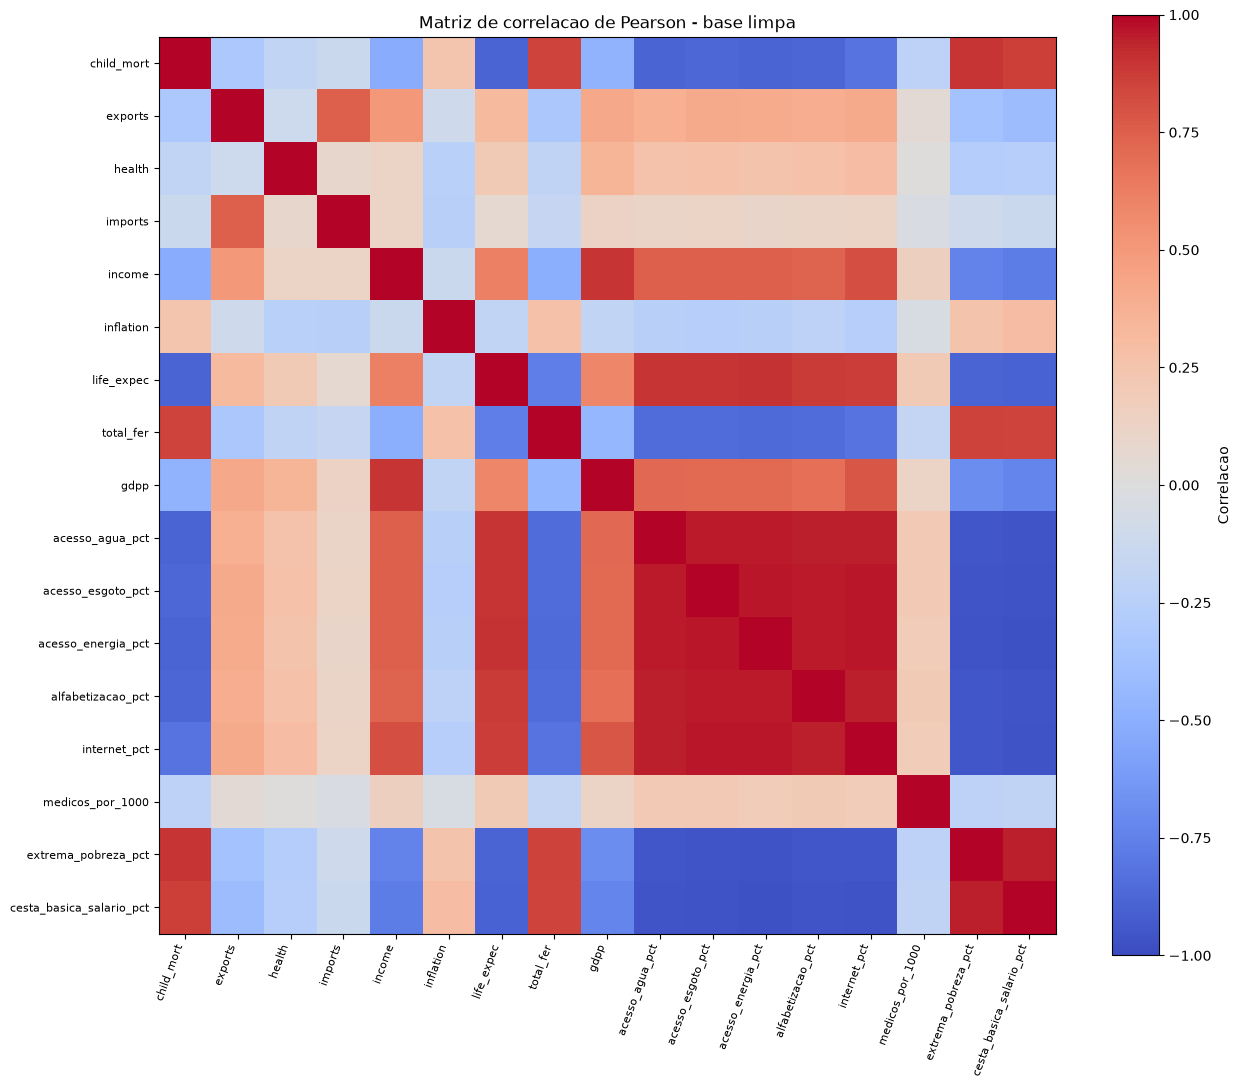

15 pares mais correlacionados (redundancia a evitar):


correlacao
acesso_energia_pct  cesta_basica_salario_pct      -0.971
internet_pct        cesta_basica_salario_pct      -0.969
acesso_esgoto_pct   acesso_energia_pct             0.968
acesso_energia_pct  extrema_pobreza_pct           -0.966
                    internet_pct                   0.965
acesso_esgoto_pct   cesta_basica_salario_pct      -0.965
                    internet_pct                   0.963
acesso_energia_pct  alfabetizacao_pct              0.961
acesso_esgoto_pct   extrema_pobreza_pct           -0.961
acesso_agua_pct     acesso_esgoto_pct              0.960
acesso_esgoto_pct   alfabetizacao_pct              0.957
acesso_agua_pct     acesso_energia_pct             0.957
                    cesta_basica_salario_pct      -0.957
alfabetizacao_pct   cesta_basica_salario_pct      -0.955
extrema_pobreza_pct cesta_basica_salario_pct       0.953

In [14]:
corr_raw = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_raw, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=70, ha="right", fontsize=8)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=8)
ax.set_title("Matriz de correlacao de Pearson - base limpa")
fig.colorbar(im, ax=ax, label="Correlacao")
fig.tight_layout()
plt.show()

pares = (
    corr_raw.where(np.triu(np.ones(corr_raw.shape), k=1).astype(bool))
    .stack().sort_values(key=np.abs, ascending=False)
)
print("15 pares mais correlacionados (redundancia a evitar):")
display(pares.head(15).to_frame("correlacao").round(3))


In [15]:
FEATURES = ["child_mort", "income", "acesso_agua_pct", "alfabetizacao_pct"]

assert len(FEATURES) == 4, "O projeto exige exatamente 4 indicadores."
assert all(c in df.columns for c in FEATURES)
print("Indicadores selecionados:", FEATURES)

print("\nCorrelacao entre os 4 escolhidos:")
print("(esperado ALTO: sao facetas do mesmo fator de desenvolvimento; ver VIF acima)")
display(df[FEATURES].corr().round(3))


Indicadores selecionados: ['child_mort', 'income', 'acesso_agua_pct', 'alfabetizacao_pct']

Correlacao entre os 4 escolhidos:
(esperado ALTO: sao facetas do mesmo fator de desenvolvimento; ver VIF acima)


,child_mort,income,acesso_agua_pct,alfabetizacao_pct
child_mort,1.000,-0.522,-0.883,-0.879
income,-0.522,1.000,0.746,0.734
acesso_agua_pct,-0.883,0.746,1.000,0.951
alfabetizacao_pct,-0.879,0.734,0.951,1.000


## 8. Pre-processamento dos indicadores: imputacao, log e escalonamento

Fluxo aplicado **somente aos 4 indicadores**. Ajuste da revisao: as tabelas finais
usam este dado limpo/imputado, nao `df_raw`.


In [16]:
X_before = df[FEATURES].copy()

# --- 8.1 Imputacao por mediana (decisao obrigatoria) ---
# Justificativa: poucos faltantes (< 10% por coluna) e a mediana e robusta a outliers
# (um valor extremo nao "puxa" a mediana como puxaria a media).
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_before), columns=FEATURES, index=df.index
)
print("Faltantes por indicador antes/depois da imputacao:")
display(pd.DataFrame({
    "antes": X_before.isna().sum(),
    "depois": X_imputed.isna().sum(),
}))

# --- 8.2 Log nas assimetricas (decisao obrigatoria) ---
LOG_FEATURES = ["child_mort", "income"]
X_transformed = X_imputed.copy()
for col in LOG_FEATURES:
    if (X_transformed[col] < 0).any():
        raise ValueError(f"{col} tem valores negativos; revise antes de aplicar log1p.")
    X_transformed[col] = np.log1p(X_transformed[col])

print("\nAssimetria antes do log:")
display(X_imputed[FEATURES].skew().to_frame("skew_antes").round(3))
print("Assimetria depois do log (apenas child_mort e income):")
display(X_transformed[FEATURES].skew().to_frame("skew_depois").round(3))


Faltantes por indicador antes/depois da imputacao:


,antes,depois
child_mort,2,0
income,1,0
acesso_agua_pct,3,0
alfabetizacao_pct,3,0



Assimetria antes do log:


,skew_antes
child_mort,1.487
income,2.236
acesso_agua_pct,-0.187
alfabetizacao_pct,-0.320


Assimetria depois do log (apenas child_mort e income):


,skew_depois
child_mort,0.073
income,-0.252
acesso_agua_pct,-0.187
alfabetizacao_pct,-0.320


### 8.3 Comparacao de imputacao: mediana x KNN (comparacao JUSTA)

Compara o metodo escolhido (**mediana**) com a alternativa **KNNImputer** aplicando
**exatamente o mesmo tratamento** nos dois ramos (log nas assimetricas + RobustScaler),
para que a diferenca no ARI seja atribuivel **so** ao metodo de imputacao - e nao a um
pre-processamento diferente em cada ramo.

> Nota metodologica: a versao anterior comparava "mediana com log" contra "KNN sem log",
> o que **confundia** o efeito do metodo de imputacao com o efeito do log. Aqui os dois
> ramos passam pelo pipeline identico.


In [17]:
def pipeline_com_imputacao(X_in):
    """Imputa (mediana ou KNN) -> log nas assimetricas -> RobustScaler -> K-Means(k=3)."""
    # 1) imputacao sobre a base JA escalonada pelo RobustScaler (KNN e sensivel a escala)
    Xr = RobustScaler().fit_transform(X_in)
    imp = SimpleImputer(strategy="median")
    knn = KNNImputer(n_neighbors=5)
    X_med = imp.fit_transform(Xr)
    X_knn = knn.fit_transform(Xr)

    # 2) MESMO pos-processamento nos dois ramos (log + reescala)
    def pos(M):
        M = pd.DataFrame(M, columns=FEATURES, index=X_in.index)
        for col in LOG_FEATURES:
            M[col] = np.log1p(M[col].clip(lower=0))
        return RobustScaler().fit_transform(M)

    return pos(X_med), pos(X_knn)


X_med_pipe, X_knn_pipe = pipeline_com_imputacao(X_before)

res_med = KMeans(n_clusters=3, n_init=50, random_state=SEED).fit_predict(X_med_pipe)
res_knn = KMeans(n_clusters=3, n_init=50, random_state=SEED).fit_predict(X_knn_pipe)
ari_imp = adjusted_rand_score(res_med, res_knn)

print("ARI entre K-Means(imputacao mediana) e K-Means(imputacao KNN):", round(ari_imp, 4))
print("\nLeitura: aqui os DOIS ramos passam pelo mesmo pipeline (log + RobustScaler),")
print("entao o ARI mede apenas o efeito do metodo de imputacao. Com ~15 valores imputados")
print("e poucos na fronteira, o ARI fica alto => o agrupamento e praticamente o mesmo.")
print("(Na versao anterior o ARI era ~0,55 porque um ramo usava log e o outro nao -")
print("isto e, comparava coisas diferentes.)")
print("\nEscolha final: MEDIANA - mais simples, robusta a outliers e sem dependencia")
print("entre features (o KNN usa as outras colunas, o que 'vaza' informacao entre")
print("indicadores correlacionados).")


ARI entre K-Means(imputacao mediana) e K-Means(imputacao KNN): 0.9606

Leitura: aqui os DOIS ramos passam pelo mesmo pipeline (log + RobustScaler),
entao o ARI mede apenas o efeito do metodo de imputacao. Com ~15 valores imputados
e poucos na fronteira, o ARI fica alto => o agrupamento e praticamente o mesmo.
(Na versao anterior o ARI era ~0,55 porque um ramo usava log e o outro nao -
isto e, comparava coisas diferentes.)

Escolha final: MEDIANA - mais simples, robusta a outliers e sem dependencia
entre features (o KNN usa as outras colunas, o que 'vaza' informacao entre
indicadores correlacionados).


### 8.4 Escalonamento (decisao obrigatoria)

`RobustScaler` (mediana + IQR): coerente com a decisao de **manter os outliers**
(secao 5). O `StandardScaler` (z-score) seria sensivel justamente aos extremos que
decidimos preservar. Distancia: **Euclidiana (L2)** - padrao para dados continuos,
poucas dimensoes, escalonados (Aula 4).


In [18]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_transformed)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=df.index)

print("Mediana apos RobustScaler (deve ficar ~0):")
display(X_scaled_df.median().round(3).to_frame("mediana"))
print("IQR apos RobustScaler (deve ficar ~1):")
display((X_scaled_df.quantile(0.75) - X_scaled_df.quantile(0.25)).round(3).to_frame("IQR"))
display(X_scaled_df.head())


Mediana apos RobustScaler (deve ficar ~0):


,mediana
child_mort,0.0
income,0.0
acesso_agua_pct,0.0
alfabetizacao_pct,0.0


IQR apos RobustScaler (deve ficar ~1):


,IQR
child_mort,1.0
income,1.0
acesso_agua_pct,1.0
alfabetizacao_pct,1.0


,child_mort,income,acesso_agua_pct,alfabetizacao_pct
0,0.793610,-0.990052,-0.936441,-1.335784
1,-0.075388,-0.013351,0.245763,-0.022059
2,0.175495,0.127152,-0.038136,0.193627
3,0.938573,-0.292881,-1.144068,-1.002451
4,-0.309439,0.337890,0.355932,0.316176


## 9. K-Means: escolha de `k` (cotovelo + silhueta + CH + DB)

Rodamos k de 2 a 10. O `k` final e decidido por **conjuncao de evidencias**, com o
desempate **escrito** (nao apenas `idxmax()`).


Metricas por k:


,k,inercia,silhueta,calinski_harabasz,davies_bouldin,queda_inercia
0,2,87.4002,0.5332,338.6076,0.6461,NaN
1,3,48.8219,0.4654,366.0431,0.7002,38.578
2,4,36.4320,0.3996,343.5030,0.8002,12.390
3,5,29.4379,0.3746,326.5028,0.9116,6.994
4,6,25.7550,0.3396,301.3149,0.9883,3.683
5,7,23.3873,0.3225,277.4989,1.0448,2.368
6,8,21.3326,0.2991,261.3234,1.0992,2.055
7,9,19.6282,0.2825,248.6652,1.1121,1.704
8,10,18.3786,0.2742,235.7567,1.0901,1.250


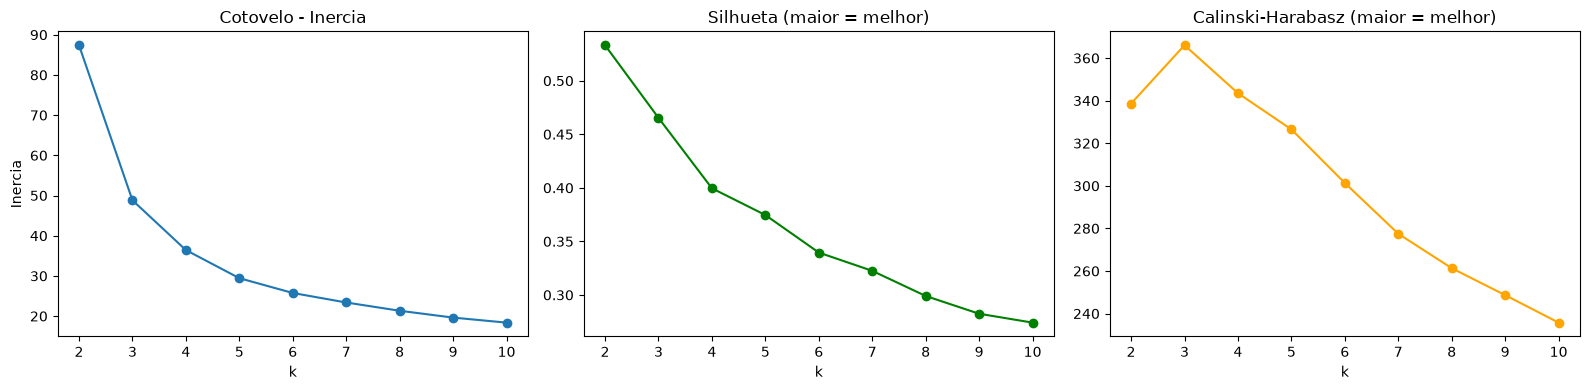

In [19]:
K_RANGE = list(range(2, 11))
metricas = []
for k in K_RANGE:
    m = KMeans(n_clusters=k, n_init=50, random_state=SEED)
    lab = m.fit_predict(X_scaled)
    metricas.append({
        "k": k,
        "inercia": m.inertia_,
        "silhueta": silhouette_score(X_scaled, lab),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, lab),
        "davies_bouldin": davies_bouldin_score(X_scaled, lab),
    })
k_eval = pd.DataFrame(metricas)
k_eval["queda_inercia"] = k_eval["inercia"].diff().abs().round(3)

print("Metricas por k:")
display(k_eval.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_eval["k"], k_eval["inercia"], marker="o")
axes[0].set_title("Cotovelo - Inercia"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(k_eval["k"], k_eval["silhueta"], marker="o", color="green")
axes[1].set_title("Silhueta (maior = melhor)"); axes[1].set_xlabel("k")
axes[2].plot(k_eval["k"], k_eval["calinski_harabasz"], marker="o", color="orange")
axes[2].set_title("Calinski-Harabasz (maior = melhor)"); axes[2].set_xlabel("k")
fig.tight_layout(); plt.show()


### 9.1 Leitura conjunta e desempate (o que o professor cobra)

- **Silhueta** e maxima em **k=2** (0,53) e a **CH** e maxima em **k=3** (366).
  Ha um **conflito** entre as metricas.
- **Cotovelo:** a maior queda de inercia e de k=2->3 (-38,6), depois a curva achata
  (-12,4, -7,0, ...). Ou seja, **o cotovelo sugere k=3**.
- **Desempate (maioria + interpretabilidade):** o cotovelo aponta k=3, a silhueta em
  k=2 e apenas ~0,07 maior que em k=3, e CH/DB pioram a partir de k=4.
  Como k=2 produz um grupo gigante **pouco acionavel** (junta renda 4.240 a 119.000),
  adotamos **k=3**, que separa **3 niveis de necessidade** interpretaveis.
- Recomendacao da Aula: na duvida, o **menor k util**. Aqui o menor k que produz
  grupos **interpretaveis para a ONG** e k=3.

> **Ponto para a banca (k=3 e defensavel, mas sabendo as limitacoes):**
> ao comparar com o Ward no mesmo k, o ARI cai de ~0,95 (em k=2) para ~0,42 (em k=3).
> Ou seja, o **terceiro grupo nao e robusto entre metodos** - os dois algoritmos
> concordam no eixo principal (rico x pobre) mas divergem em onde cortar o nivel
> intermediario. Isso **nao invalida** o k=3 (K-Means e estavel entre sementes, com
> ARI ~0,96), mas mostra que o **limite** entre o perfil intermediario e os vizinhos
> deve ser tratado como **zona de transicao**, nao como fronteira nitida. A recomendacao
> para a ONG: usar os perfis como **priorizacao**, nao como classificacao binaria.


In [20]:
K_FINAL = 3
print("k definitivo (desempate documentado acima):", K_FINAL)


k definitivo (desempate documentado acima): 3


## 10. Agrupamento final com K-Means


In [21]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, random_state=SEED)
labels_kmeans = kmeans.fit_predict(X_scaled)

print("Metricas K-Means (k=3):")
print("Silhueta:", round(silhouette_score(X_scaled, labels_kmeans), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, labels_kmeans), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, labels_kmeans), 4))
print("\nTamanho dos clusters:")
display(pd.Series(labels_kmeans).value_counts().sort_index().to_frame("n_paises"))


Metricas K-Means (k=3):
Silhueta: 0.4654
Calinski-Harabasz: 366.0431
Davies-Bouldin: 0.7002

Tamanho dos clusters:


,n_paises
0,59
1,60
2,48


### 10.1 Estabilidade com varias sementes

Verifica se o k=3 e estavel trocando `random_state`.


In [22]:
base = KMeans(n_clusters=K_FINAL, n_init=50, random_state=SEED).fit_predict(X_scaled)
aris = []
for seed in range(1, 11):
    lab_seed = KMeans(n_clusters=K_FINAL, n_init=50, random_state=seed).fit_predict(X_scaled)
    aris.append(adjusted_rand_score(base, lab_seed))
print("ARI medio entre sementes:", round(float(np.mean(aris)), 4))
print("ARI minimo:", round(float(np.min(aris)), 4), "-> >=0.8 indica solucao estavel")


ARI medio entre sementes: 0.962
ARI minimo: 0.962 -> >=0.8 indica solucao estavel


## 11. Perfil dos clusters (BASE LIMPA - correcao do item 1 da revisao)

Usamos o dado **limpo/imputado** (`X_imputed`), nao `df_raw`. Assim a mediana de
`income` do grupo vulneravel aparece corretamente (~1.865), sem a sentinela 99999 do
Bangladesh contaminando a tabela.


In [23]:
perfil = df[["country"]].copy()

# Ajuste da revisao: valores LIMPOS/imputados entram na tabela final
perfil[FEATURES] = X_imputed[FEATURES]
perfil["cluster"] = labels_kmeans

perfil_mediano = perfil.groupby("cluster")[FEATURES].median()
perfil_mediano["n_paises"] = perfil.groupby("cluster").size()
print("Perfil mediano por cluster (dado limpo):")
display(perfil_mediano.round(2))

print("\nCentroides no espaco padronizado:")
centroides = pd.DataFrame(X_scaled, columns=FEATURES, index=df.index)
centroides["cluster"] = labels_kmeans
display(centroides.groupby("cluster")[FEATURES].mean().round(3))


Perfil mediano por cluster (dado limpo):


,child_mort,income,acesso_agua_pct,alfabetizacao_pct,n_paises
cluster,,,,,
0,21.50,9720.0,73.10,77.60,59
1,5.80,31350.0,90.90,90.75,60
2,88.75,1860.0,55.45,61.00,48



Centroides no espaco padronizado:


,child_mort,income,acesso_agua_pct,alfabetizacao_pct
cluster,,,,
0,0.121,-0.051,-0.080,-0.114
1,-0.546,0.602,0.643,0.589
2,0.743,-0.885,-0.821,-0.871


### 11.1 Nomeacao dos perfis

Ordenamos os clusters pela mortalidade infantil mediana e nomeamos cada um.


In [24]:
ordem = perfil_mediano["child_mort"].sort_values(ascending=False).index.tolist()
nomes = [
    "Perfil 1 - Alta necessidade (saude/renda/infra baixas)",
    "Perfil 2 - Necessidade intermediaria",
    "Perfil 3 - Baixa necessidade / maior capacidade",
]
mapa_nomes = dict(zip(ordem, nomes))
perfil["perfil"] = perfil["cluster"].map(mapa_nomes)

print("Perfis definidos:")
for c in ordem:
    print(f"  Cluster {c}: {mapa_nomes[c]}")

resumo_perfil = perfil.groupby("perfil")[FEATURES].median()
resumo_perfil["n_paises"] = perfil.groupby("perfil").size()
print("\nResumo por perfil:")
display(resumo_perfil.round(1))


Perfis definidos:
  Cluster 2: Perfil 1 - Alta necessidade (saude/renda/infra baixas)
  Cluster 0: Perfil 2 - Necessidade intermediaria
  Cluster 1: Perfil 3 - Baixa necessidade / maior capacidade

Resumo por perfil:


,child_mort,income,acesso_agua_pct,alfabetizacao_pct,n_paises
perfil,,,,,
Perfil 1 - Alta necessidade (saude/renda/infra baixas),88.8,1860.0,55.4,61.0,48
Perfil 2 - Necessidade intermediaria,21.5,9720.0,73.1,77.6,59
Perfil 3 - Baixa necessidade / maior capacidade,5.8,31350.0,90.9,90.8,60


## 12. Agrupamento hierarquico (Ward) e comparacao

`linkage(method="ward")`, dendrograma e corte com `fcluster(..., criterion="maxclust")`
(**numero de grupos**, nunca `distance`).


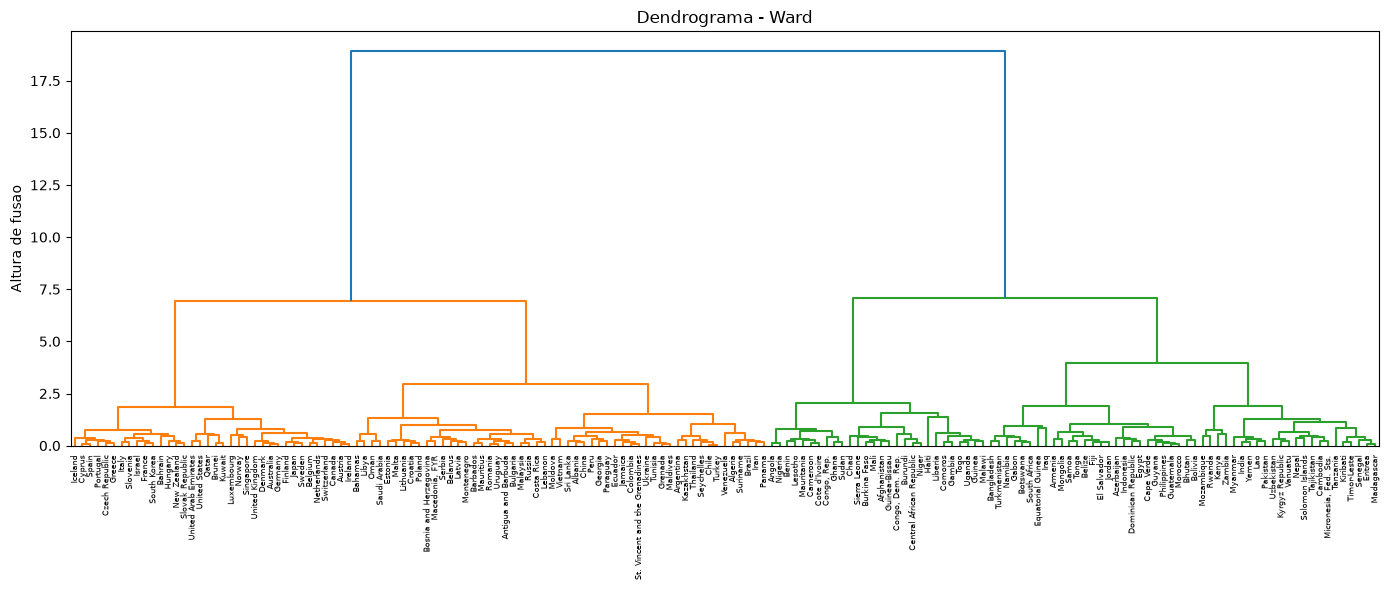

In [25]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=df["country"].values, leaf_rotation=90, leaf_font_size=6, ax=ax)
ax.set_title("Dendrograma - Ward")
ax.set_ylabel("Altura de fusao")
plt.tight_layout(); plt.show()


In [26]:
ward_eval = []
for k in K_RANGE:
    lw = fcluster(Z, t=k, criterion="maxclust")
    ward_eval.append({
        "k": k,
        "silhueta": silhouette_score(X_scaled, lw),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, lw),
        "davies_bouldin": davies_bouldin_score(X_scaled, lw),
    })
ward_eval = pd.DataFrame(ward_eval)
display(ward_eval.round(4))


,k,silhueta,calinski_harabasz,davies_bouldin
0,2,0.5320,336.4925,0.6480
1,3,0.4320,266.0529,0.7835
2,4,0.3953,319.7912,0.7830
3,5,0.3700,308.6358,0.9184
4,6,0.3233,291.2787,1.0010
5,7,0.2957,264.3237,1.0416
6,8,0.2994,245.4332,1.0288
7,9,0.2945,233.8108,1.0366
8,10,0.2566,226.5189,1.0850


In [27]:
labels_ward = fcluster(Z, t=K_FINAL, criterion="maxclust")
ari_final = adjusted_rand_score(labels_kmeans, labels_ward)

print(f"Comparacao K-Means x Ward (mesmo k={K_FINAL}):")
print("Silhueta K-Means:", round(silhouette_score(X_scaled, labels_kmeans), 4))
print("Silhueta Ward   :", round(silhouette_score(X_scaled, labels_ward), 4))
print("ARI K-Means x Ward:", round(ari_final, 4))
print("\nTabela de concordancia (K-Means x Ward):")
display(pd.crosstab(labels_kmeans, labels_ward))

print("\nNota: em k=2 a concordancia e altissima (ARI ~0.95). No k=3 os metodos cortam")
print("a hierarquia em pontos diferentes, o que baixa o ARI - nao e erro, e sim")
print("evidencia de que o 3o nivel e menos separado. Mantemos K-Means por ser mais")
print("estavel (ver 10.1) e ter silhueta igual/melhor.")


Comparacao K-Means x Ward (mesmo k=3):
Silhueta K-Means: 0.4654
Silhueta Ward   : 0.432
ARI K-Means x Ward: 0.4162

Tabela de concordancia (K-Means x Ward):


col_0,1,2,3
row_0,,,
0,29,0,30
1,60,0,0
2,0,28,20



Nota: em k=2 a concordancia e altissima (ARI ~0.95). No k=3 os metodos cortam
a hierarquia em pontos diferentes, o que baixa o ARI - nao e erro, e sim
evidencia de que o 3o nivel e menos separado. Mantemos K-Means por ser mais
estavel (ver 10.1) e ter silhueta igual/melhor.


## 13. Tabela final: pais -> cluster -> perfil (BASE LIMPA)

Tabela que vai para o relatorio e o slide. **Todos os valores sao os limpos/imputados**
usados no modelo (correcao do item 1 da revisao).


In [28]:
tabela_final = perfil[["country", "cluster", "perfil"] + FEATURES].copy()
tabela_final = tabela_final.sort_values(["cluster", "country"]).reset_index(drop=True)

display(tabela_final.head(20))

for c in sorted(tabela_final["cluster"].unique()):
    grupo = tabela_final[tabela_final["cluster"] == c]
    print(f"\n{'=' * 70}")
    print(f"CLUSTER {c} - {mapa_nomes[c]} ({len(grupo)} paises)")
    print(f"{'=' * 70}")
    display(grupo[["country"] + FEATURES].reset_index(drop=True))


,country,cluster,perfil,child_mort,income,acesso_agua_pct,alfabetizacao_pct
0,Albania,0,Perfil 2 - Necessidade intermediaria,16.6,9930.0,81.2,79.4
1,Algeria,0,Perfil 2 - Necessidade intermediaria,27.3,12900.0,74.5,83.8
2,Argentina,0,Perfil 2 - Necessidade intermediaria,14.5,18700.0,78.6,82.1
3,Armenia,0,Perfil 2 - Necessidade intermediaria,18.1,6700.0,77.9,74.2
4,Azerbaijan,0,Perfil 2 - Necessidade intermediaria,39.2,16000.0,71.6,77.4
5,Bangladesh,0,Perfil 2 - Necessidade intermediaria,49.4,10180.0,70.2,73.5
6,Belize,0,Perfil 2 - Necessidade intermediaria,18.8,7880.0,67.8,76.4
7,Bhutan,0,Perfil 2 - Necessidade intermediaria,42.7,6420.0,64.0,75.2
8,Bolivia,0,Perfil 2 - Necessidade intermediaria,46.6,5410.0,63.3,70.5
9,Bosnia and Herzegovina,0,Perfil 2 - Necessidade intermediaria,6.9,9720.0,77.4,84.4



CLUSTER 0 - Perfil 2 - Necessidade intermediaria (59 paises)


,country,child_mort,income,acesso_agua_pct,alfabetizacao_pct
0,Albania,16.6,9930.0,81.2,79.4
1,Algeria,27.3,12900.0,74.5,83.8
2,Argentina,14.5,18700.0,78.6,82.1
3,Armenia,18.1,6700.0,77.9,74.2
4,Azerbaijan,39.2,16000.0,71.6,77.4
5,Bangladesh,49.4,10180.0,70.2,73.5
6,Belize,18.8,7880.0,67.8,76.4
7,Bhutan,42.7,6420.0,64.0,75.2
8,Bolivia,46.6,5410.0,63.3,70.5
9,Bosnia and Herzegovina,6.9,9720.0,77.4,84.4



CLUSTER 1 - Perfil 3 - Baixa necessidade / maior capacidade (60 paises)


,country,child_mort,income,acesso_agua_pct,alfabetizacao_pct
0,Antigua and Barbuda,10.3,19100.0,83.8,86.3
1,Australia,4.8,41400.0,100.0,95.5
2,Austria,4.3,43200.0,94.2,96.5
3,Bahamas,13.8,22900.0,90.9,90.2
4,Bahrain,8.6,41100.0,91.4,87.6
5,Barbados,14.2,15300.0,83.0,88.6
6,Belarus,5.5,16200.0,80.7,88.1
7,Belgium,4.5,41100.0,97.1,100.0
8,Brunei,10.5,80600.0,98.8,100.0
9,Bulgaria,10.8,15300.0,83.4,85.0



CLUSTER 2 - Perfil 1 - Alta necessidade (saude/renda/infra baixas) (48 paises)


,country,child_mort,income,acesso_agua_pct,alfabetizacao_pct
0,Afghanistan,90.2,1610.0,53.3,52.60
1,Angola,119.0,5900.0,48.4,59.40
2,Benin,111.0,1820.0,53.8,57.70
3,Burkina Faso,116.0,1430.0,49.0,55.00
4,Burundi,93.6,764.0,40.6,54.50
5,Cambodia,44.4,2520.0,64.7,68.60
6,Cameroon,108.0,2660.0,54.7,56.20
7,Central African Republic,149.0,888.0,44.7,51.10
8,Chad,150.0,1930.0,43.3,51.00
9,Comoros,88.2,1410.0,57.4,60.10


## 14. Recomendacao a diretoria (estrategia por perfil)

Traduzimos os perfis em **estrategias diferentes** de ajuda (o produto central).


In [29]:
estrategias = {
    "Perfil 1 - Alta necessidade (saude/renda/infra baixas)":
        "Prioridade maxima. Foco em saude infantil, agua/saneamento e transferencia de "
        "renda. Maior parcela do fundo; intervencoes estruturais e de longo prazo.",
    "Perfil 2 - Necessidade intermediaria":
        "Prioridade media. Foco em infraestrutura de acesso (agua/esgoto) e educacao, "
        "com apoio a programas de saude publica. Parcela intermediaria do fundo.",
    "Perfil 3 - Baixa necessidade / maior capacidade":
        "Prioridade baixa. Apenas apoio pontual/fortalecimento institucional. Menor "
        "parcela do fundo; atuacao em parceria com governos locais.",
}

for perfil_nome, estrategia in estrategias.items():
    n = int((perfil["perfil"] == perfil_nome).sum())
    print(f"{perfil_nome}")
    print(f"  n_paises: {n}")
    print(f"  estrategia: {estrategia}\n")


Perfil 1 - Alta necessidade (saude/renda/infra baixas)
  n_paises: 48
  estrategia: Prioridade maxima. Foco em saude infantil, agua/saneamento e transferencia de renda. Maior parcela do fundo; intervencoes estruturais e de longo prazo.

Perfil 2 - Necessidade intermediaria
  n_paises: 59
  estrategia: Prioridade media. Foco em infraestrutura de acesso (agua/esgoto) e educacao, com apoio a programas de saude publica. Parcela intermediaria do fundo.

Perfil 3 - Baixa necessidade / maior capacidade
  n_paises: 60
  estrategia: Prioridade baixa. Apenas apoio pontual/fortalecimento institucional. Menor parcela do fundo; atuacao em parceria com governos locais.



## 15. Exportacao dos resultados

Salva as tabelas na pasta **`outputs/` na raiz do projeto** (independente de onde o
notebook for executado: se rodar de `notebooks/`, sobe um nivel). A pasta e ignorada
pelo git, exceto o `.gitkeep`.


In [30]:
# Ancora a saida na raiz do projeto, funcione o notebook rodando de onde for.
_cwd = Path.cwd()
RAIZ = _cwd.parent if _cwd.name == "notebooks" else _cwd
OUTPUT_DIR = RAIZ / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / ".gitkeep").touch(exist_ok=True)

eda_raw.to_csv(OUTPUT_DIR / "01_eda_descritiva_bruta.csv", encoding="utf-8-sig")
outliers_iqr.to_csv(OUTPUT_DIR / "02_outliers_iqr.csv", index=False, encoding="utf-8-sig")
auditoria_limpeza.to_csv(OUTPUT_DIR / "03_auditoria_limpeza.csv", index=False, encoding="utf-8-sig")
k_eval.to_csv(OUTPUT_DIR / "04_kmeans_metricas.csv", index=False, encoding="utf-8-sig")
ward_eval.to_csv(OUTPUT_DIR / "05_ward_metricas.csv", index=False, encoding="utf-8-sig")
perfil_mediano.to_csv(OUTPUT_DIR / "06_perfil_mediano.csv", encoding="utf-8-sig")
tabela_final.to_csv(OUTPUT_DIR / "07_paises_clusters.csv", index=False, encoding="utf-8-sig")

print("Resultados exportados para:", OUTPUT_DIR.resolve())


Resultados exportados para: C:\Users\win\OneDrive\repos\mineracao_4semestre_paises\outputs


## 16. Resumo das decisoes (resposta as 6 perguntas do enunciado)

| Pergunta | Resposta |
|---|---|
| **Quais indicadores?** | `child_mort`, `income`, `acesso_agua_pct`, `alfabetizacao_pct`. Selecionados pelo heatmap de correlacao para **minimizar redundancia**; reconhece-se que sao **facetas colineares** de um mesmo fator de desenvolvimento (VIF alto), nao dimensoes independentes. |
| **Preenchimento dos faltantes?** | Sentinela/impossiveis -> `NaN`, depois **imputacao por mediana**. KNN comparado em pipeline **identico** (ARI ~0,96): o agrupamento praticamente nao muda; mantemos a mediana (mais simples, robusta e sem vazamento entre features). |
| **Tratamento dos outliers?** | Detectados por **IQR**; **mantidos** por serem extremos legitimos (pobreza/riqueza real). Erros grosseiros tratados na limpeza. |
| **Assimetria?** | **Sim**, tratada com `log1p` em `child_mort` e `income` (skew cai para ~0). Escalonar nao resolve assimetria; log muda a forma. |
| **Escalonamento?** | **Sim**, `RobustScaler` (mediana + IQR), coerente com manter outliers. |
| **Metrica de distancia?** | **Euclidiana (L2)**, combinando com dados continuos, poucas dimensoes e escalonamento. |

**Agrupamento final:** K-Means com **k=3** (cotovelo + CH favorecem k=3; silhueta maxima em
k=2 por 0,07, mas k=2 gera grupo pouco acionavel). Interpretado em 3 perfis de necessidade,
comparado ao Ward e validado por estabilidade entre sementes.
